# Use case — clustering a real dataset (handwritten digits)

A real, recognizable dataset end-to-end: scikit-learn's **`digits`** — 1797 handwritten digits as
8×8 grayscale images (64 features), 10 true classes (0–9). We cluster it with `betula-cluster`,
check it matches scikit-learn's k-means on a real (imperfect) dataset, and use the inspection API to
*see* what each cluster learned — its average-digit centroid and exemplar images.

```bash
pip install betula-cluster matplotlib seaborn pandas scikit-learn
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

import betula_cluster

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

## The data — real handwritten digits

`X_raw` holds the 0–16 pixel intensities; `X` is the standardized matrix we cluster on; `y` is the
true digit for scoring only (clustering is unsupervised).

digits: 1797 images × 64 pixels (8×8), 10 classes


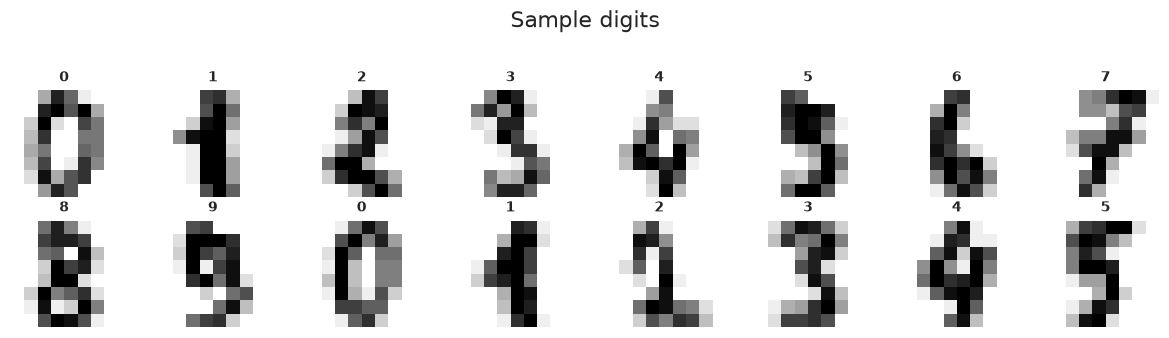

In [2]:
X_raw, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X_raw).astype(np.float64)
print(f"digits: {X.shape[0]} images × {X.shape[1]} pixels (8×8), {len(set(y))} classes")

fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for ax, img, lab in zip(axes.ravel(), X_raw, y, strict=False):
    ax.imshow(img.reshape(8, 8), cmap="gray_r")
    ax.set_title(int(lab), fontsize=9)
    ax.set_axis_off()
fig.suptitle("Sample digits", y=1.02)
plt.tight_layout()
plt.show()

## Cluster it — and check parity with scikit-learn

Real data is imperfect: digits like 1/8/9 overlap, so no method reaches ARI 1. The point is that
**betula matches scikit-learn** — the CF-tree compression costs nothing in quality — at every head.

In [3]:
labels = np.asarray(betula_cluster.fit_predict(X, 10, feature="spherical", method="kmeans", threshold=0.0, max_leaves=1000, seed=0))
labels_full = np.asarray(betula_cluster.fit_predict(X, 10, feature="full", method="gmm-full", threshold=0.0, max_leaves=1000, seed=0))
sk = KMeans(10, n_init=10, random_state=0).fit_predict(X)
pd.DataFrame(
    {
        "method": ["betula-kmeans", "betula-gmm-full", "sklearn-kmeans"],
        "ARI": [adjusted_rand_score(y, labels), adjusted_rand_score(y, labels_full), adjusted_rand_score(y, sk)],
        "AMI": [adjusted_mutual_info_score(y, labels), adjusted_mutual_info_score(y, labels_full), adjusted_mutual_info_score(y, sk)],
    }
).round(3)

,method,ARI,AMI
0,betula-kmeans,0.440,0.588
1,betula-gmm-full,0.412,0.611
2,sklearn-kmeans,0.468,0.622


## What did each cluster learn? — average-digit centroids

Averaging the raw images in each cluster gives its "prototype" digit. Most clusters resolve to a
clean, recognizable numeral — the unsupervised structure lines up with the real classes.

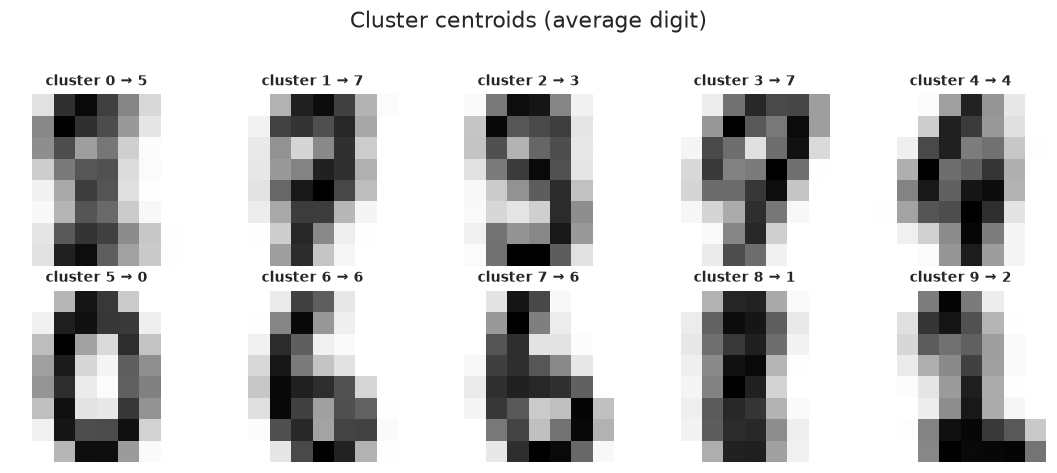

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
for c, ax in enumerate(axes.ravel()):
    members = X_raw[labels == c]
    ax.imshow(members.mean(0).reshape(8, 8), cmap="gray_r")
    # the majority true digit in this cluster, for a sanity label
    maj = np.bincount(y[labels == c]).argmax()
    ax.set_title(f"cluster {c} → {maj}", fontsize=9)
    ax.set_axis_off()
fig.suptitle("Cluster centroids (average digit)", y=1.02)
plt.tight_layout()
plt.show()

## Exemplars — the most typical image per cluster

`representatives(..., method="medoid")` returns the rows closest to a cluster's centroid: a compact,
human-readable summary of each cluster without scanning thousands of images.

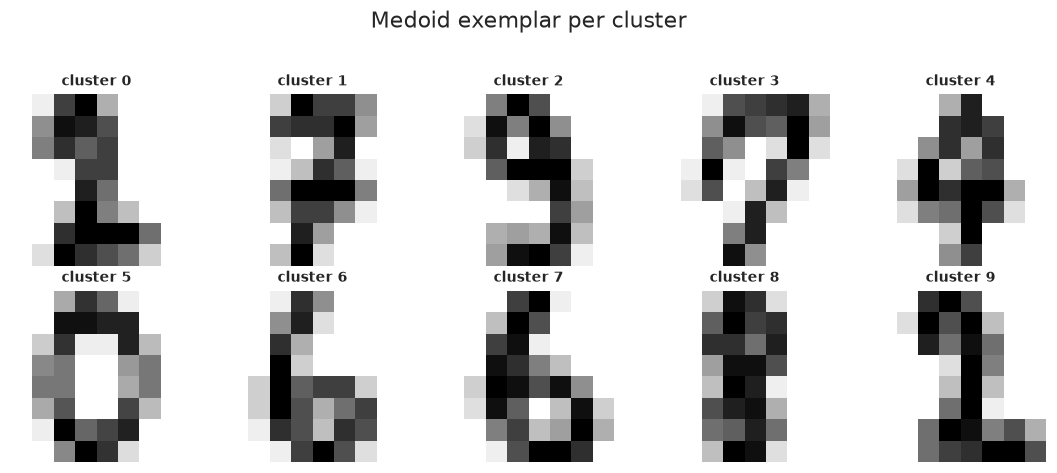

In [5]:
est = betula_cluster.Betula(n_clusters=10, feature="spherical", method="kmeans", threshold=0.0, max_leaves=1000, seed=0).fit(X)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
for c, ax in enumerate(axes.ravel()):
    reps = np.asarray(est.representatives(X, cluster_id=c, method="medoid", k=1))
    ax.imshow(X_raw[reps[0]].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"cluster {c}", fontsize=9)
    ax.set_axis_off()
fig.suptitle("Medoid exemplar per cluster", y=1.02)
plt.tight_layout()
plt.show()

## A coreset reproduces the result at a fraction of the size

`export_coreset()` returns the CF-tree leaves as weighted points. Fitting scikit-learn k-means on
the coreset (a few hundred weighted rows) gives essentially the same labels as fitting on all 1797
images — the compression is lossless for this task.

In [6]:
core = est.export_coreset()
km_full = KMeans(10, n_init=10, random_state=0).fit(X)
km_core = KMeans(10, n_init=10, random_state=0).fit(core.centers, sample_weight=core.weights)
pd.DataFrame(
    {
        "metric": ["rows fit on (coreset vs full)", "ARI: coreset labels vs full-data labels"],
        "value": [
            f"{len(core.centers)} weighted leaves vs {len(X)} images",
            round(adjusted_rand_score(km_full.predict(X), km_core.predict(X)), 3),
        ],
    }
)

,metric,value
0,rows fit on (coreset vs full),879 weighted leaves vs 1797 images
1,ARI: coreset labels vs full-data labels,0.796


## Takeaway

On a real dataset, `betula-cluster` matches scikit-learn's quality while exposing the structure
(centroids, exemplars, a refit-anything coreset) over the microclusters it already built — and it
does so at bounded memory, so the identical code scales from 1797 images to tens of millions. For
the at-scale numbers on real data (covtype, MNIST) see [`bench/RESULTS.md`](../../bench/RESULTS.md).